# Experiment 0.1.2 — Regularized General Comparison
Analysis-only notebook. Training and evaluation are performed by the Slurm array; this notebook reads finalized artifacts only.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'scripts').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ART = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_0_1_2_regularized_general_comparison' / 'regularized_general_comparison_v1'
manifest = json.loads((ART / 'manifest.json').read_text())
manifest


{'base_experiment': {'experiment_id': 'experiment_0_1_general_comparison',
  'protocol_version': 'general_comparison_v1',
  'reuse': '60 frozen direct reg-off runs + frozen probe/context and raw baselines'},
 'direct_architectures': {'mid_long': [[2, 3, 4, 5], [2, 3, 4, 5, 6, 7]],
  'short_mid': [[2, 3], [2, 3, 4, 5]],
  'short_mid_long': [[2, 3], [2, 3, 4, 5], [2, 3, 4, 5, 6, 7]]},
 'experiment_id': 'experiment_0_1_2_regularized_general_comparison',
 'files': {'baselines': 'baseline_results.csv',
  'comparison_summary': 'comparison_summary.csv',
  'paired_regularization_effects': 'paired_regularization_effects.csv',
  'regularization_architecture_interactions': 'regularization_architecture_interactions.csv',
  'regularization_capacity_interactions': 'regularization_capacity_interactions.csv',
  'regularization_objective_interactions': 'regularization_objective_interactions.csv',
  'runs': 'runs.csv',
  'summary': 'summary.csv'},
 'new_training_run_count': 60,
 'objectives': ['whole_co

In [2]:
runs = pd.read_csv(ART / 'runs.csv')
summary = pd.read_csv(ART / 'summary.csv')
comparison = pd.read_csv(ART / 'comparison_summary.csv')
paired = pd.read_csv(ART / 'paired_regularization_effects.csv')
objective_interactions = pd.read_csv(ART / 'regularization_objective_interactions.csv')
capacity_interactions = pd.read_csv(ART / 'regularization_capacity_interactions.csv')
architecture_interactions = pd.read_csv(ART / 'regularization_architecture_interactions.csv')
display(summary.sort_values('test_ba_mean', ascending=False).head(30))
display(comparison.sort_values('mean_test_ba', ascending=False).head(30))


,family,architecture,objective,variant,regularization,primary_readout,test_ba_mean,test_ba_std,test_ba_count,test_accuracy_mean,...,test_accuracy_count,test_macro_f1_mean,test_macro_f1_std,test_macro_f1_count,native_test_ba_mean,native_test_ba_std,native_test_ba_count,test_last_hidden_events_per_neuron_second_mean,test_last_hidden_events_per_neuron_second_std,test_last_hidden_events_per_neuron_second_count
25,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,not_applicable,l2_fixed250_ordered_linear,0.600974,0.014364,5,0.617808,...,5,0.604736,0.016878,5,0.496383,0.023188,5,61.280235,5.162455,5
24,snn_fixed250_linear,local_234x2,timestep_ce,binary,not_applicable,l2_fixed250_ordered_linear,0.595437,0.032058,5,0.610959,...,5,0.591023,0.039427,5,0.498173,0.031295,5,16.349006,1.048725,5
12,direct_snn,short_mid,whole_count_ce,binary,off,output_whole_count,0.457210,0.026985,5,0.472603,...,5,0.435882,0.040386,5,0.457210,0.026985,5,9.917578,0.874293,5
14,direct_snn,short_mid,whole_count_ce,multi_h,off,output_whole_count,0.434573,0.024067,5,0.450685,...,5,0.413727,0.021039,5,0.434573,0.024067,5,37.278852,5.736842,5
6,direct_snn,mid_long,whole_count_ce,multi_h,off,output_whole_count,0.413762,0.011693,5,0.424658,...,5,0.393367,0.020867,5,0.413762,0.011693,5,35.101234,6.136573,5
4,direct_snn,mid_long,whole_count_ce,binary,off,output_whole_count,0.400790,0.030637,5,0.413699,...,5,0.381113,0.030675,5,0.400790,0.030637,5,11.645353,0.866013,5
0,direct_snn,mid_long,timestep_ce,binary,off,output_whole_count,0.304034,0.044997,5,0.319178,...,5,0.240477,0.045242,5,0.304034,0.044997,5,8.332745,1.777456,5
10,direct_snn,short_mid,timestep_ce,multi_h,off,output_whole_count,0.292169,0.027146,5,0.309589,...,5,0.235960,0.017161,5,0.292169,0.027146,5,10.080790,2.396412,5
8,direct_snn,short_mid,timestep_ce,binary,off,output_whole_count,0.281464,0.025165,5,0.300000,...,5,0.221717,0.031170,5,0.281464,0.025165,5,3.639480,0.918831,5
2,direct_snn,mid_long,timestep_ce,multi_h,off,output_whole_count,0.238677,0.058816,5,0.247945,...,5,0.178689,0.064408,5,0.238677,0.058816,5,21.273194,8.250361,5


,system,family,architecture,objective,variant,regularization,mean_test_ba,sd_test_ba,n
27,Raw Relative10 + Linear,raw_linear_baseline,relative10,posthoc_linear,deterministic,not_applicable,0.739481,NaN,1
25,snn_fixed250_linear:local_234x2:timestep_ce:mu...,snn_fixed250_linear,local_234x2,timestep_ce,multi_h,not_applicable,0.600974,0.014364,5
24,snn_fixed250_linear:local_234x2:timestep_ce:bi...,snn_fixed250_linear,local_234x2,timestep_ce,binary,not_applicable,0.595437,0.032058,5
26,Raw Fixed250 + Linear,raw_linear_baseline,fixed250,posthoc_linear,deterministic,not_applicable,0.548475,NaN,1
12,direct_snn:short_mid:whole_count_ce:binary:reg...,direct_snn,short_mid,whole_count_ce,binary,off,0.457210,0.026985,5
14,direct_snn:short_mid:whole_count_ce:multi_h:re...,direct_snn,short_mid,whole_count_ce,multi_h,off,0.434573,0.024067,5
6,direct_snn:mid_long:whole_count_ce:multi_h:reg...,direct_snn,mid_long,whole_count_ce,multi_h,off,0.413762,0.011693,5
4,direct_snn:mid_long:whole_count_ce:binary:reg=off,direct_snn,mid_long,whole_count_ce,binary,off,0.400790,0.030637,5
0,direct_snn:mid_long:timestep_ce:binary:reg=off,direct_snn,mid_long,timestep_ce,binary,off,0.304034,0.044997,5
10,direct_snn:short_mid:timestep_ce:multi_h:reg=off,direct_snn,short_mid,timestep_ce,multi_h,off,0.292169,0.027146,5


## Paired regularization effect
Positive `delta_test_ba_reg_on_minus_off` means the hidden P2+A1 condition improved test BA for the same architecture/objective/capacity/seed.


In [3]:
paired_summary = (
    paired.groupby(['architecture', 'objective', 'variant'])['delta_test_ba_reg_on_minus_off']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values('mean', ascending=False)
)
display(paired_summary)
display(paired.groupby(['objective', 'variant'])['delta_test_ba_reg_on_minus_off'].agg(['mean', 'std', 'count']))


,architecture,objective,variant,mean,std,count
8,short_mid_long,timestep_ce,binary,-0.047905,0.015754,5
9,short_mid_long,timestep_ce,multi_h,-0.051818,0.013454,5
11,short_mid_long,whole_count_ce,multi_h,-0.105856,0.032047,5
10,short_mid_long,whole_count_ce,binary,-0.134524,0.014942,5
1,mid_long,timestep_ce,multi_h,-0.162162,0.062808,5
4,short_mid,timestep_ce,binary,-0.198130,0.025165,5
5,short_mid,timestep_ce,multi_h,-0.208835,0.027146,5
0,mid_long,timestep_ce,binary,-0.218926,0.047715,5
2,mid_long,whole_count_ce,binary,-0.310941,0.033007,5
3,mid_long,whole_count_ce,multi_h,-0.330426,0.018649,5


mean       std  count
objective      variant                           
timestep_ce    binary  -0.154987  0.084394     15
               multi_h -0.140939  0.077674     15
whole_count_ce binary  -0.273114  0.107610     15
               multi_h -0.262507  0.117396     15

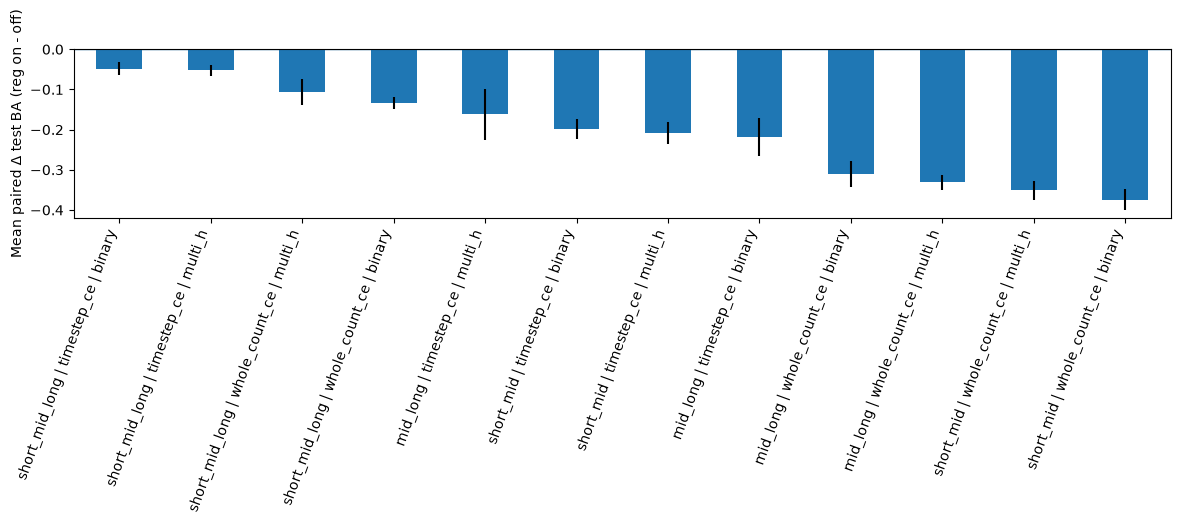

In [4]:
plot_df = paired_summary.copy()
plot_df['condition'] = plot_df['architecture'] + ' | ' + plot_df['objective'] + ' | ' + plot_df['variant']
ax = plot_df.plot.bar(x='condition', y='mean', yerr='std', legend=False, figsize=(12, 5))
ax.axhline(0.0, linewidth=1)
ax.set_ylabel('Mean paired Δ test BA (reg on - off)')
ax.set_xlabel('')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()


## Interaction checks


In [5]:
display(objective_interactions.groupby(['architecture', 'variant'])['interaction_reg_delta_timestep_minus_whole_count'].agg(['mean', 'std', 'count']))
display(capacity_interactions.groupby(['architecture', 'objective'])['interaction_reg_delta_multi_h_minus_binary'].agg(['mean', 'std', 'count']))
display(architecture_interactions.groupby(['comparison', 'objective', 'variant'])['interaction_reg_delta_candidate_minus_baseline'].agg(['mean', 'std', 'count']))


mean       std  count
architecture   variant                           
mid_long       binary   0.092015  0.052556      5
               multi_h  0.168264  0.070322      5
short_mid      binary   0.175747  0.030838      5
               multi_h  0.142404  0.040587      5
short_mid_long binary   0.086619  0.025193      5
               multi_h  0.054037  0.030463      5

mean       std  count
architecture   objective                                
mid_long       timestep_ce     0.056764  0.059770      5
               whole_count_ce -0.019484  0.026980      5
short_mid      timestep_ce    -0.010705  0.029899      5
               whole_count_ce  0.022637  0.044698      5
short_mid_long timestep_ce    -0.003913  0.025638      5
               whole_count_ce  0.028668  0.024324      5

mean       std  count
comparison            objective      variant                           
add_long_layer        timestep_ce    binary   0.150225  0.030797      5
                                     multi_h  0.157017  0.030697      5
                      whole_count_ce binary   0.239353  0.024204      5
                                     multi_h  0.245384  0.043479      5
shift_coverage_longer timestep_ce    binary  -0.020796  0.058269      5
                                     multi_h  0.046674  0.050896      5
                      whole_count_ce binary   0.062936  0.013811      5
                                     multi_h  0.020814  0.035412      5

## Reg-on neuron-health diagnostics
The frozen Exp0.1 reg-off rows do not contain the new dead/cap diagnostics, so these columns are interpreted only within reg-on runs. The paired last-hidden event-rate delta remains available for reg-on vs reg-off.


In [6]:
reg_on = runs[(runs['family'] == 'direct_snn') & (runs['regularization'] == 'on')]
diag_cols = [
    'test_mean_dead_neuron_fraction',
    'test_mean_active_step_fraction',
    'test_mean_fraction_at_cap',
    'test_last_hidden_dead_neuron_fraction',
    'test_last_hidden_active_step_fraction',
    'test_last_hidden_fraction_at_cap',
]
display(reg_on.groupby(['architecture', 'objective', 'variant'])[diag_cols].mean())
display(paired.groupby(['architecture', 'objective', 'variant'])['delta_last_hidden_events_per_neuron_second'].agg(['mean', 'std', 'count']))


test_mean_dead_neuron_fraction  \
architecture   objective      variant                                   
mid_long       timestep_ce    binary                         0.253906   
                              multi_h                        0.198437   
               whole_count_ce binary                         0.215625   
                              multi_h                        0.195312   
short_mid      timestep_ce    binary                         0.628125   
                              multi_h                        0.628125   
               whole_count_ce binary                         0.628125   
                              multi_h                        0.628125   
short_mid_long timestep_ce    binary                         0.530729   
                              multi_h                        0.468229   
               whole_count_ce binary                         0.570312   
                              multi_h                        0.474479   

                                       test_mean_active_step_fraction  \
architecture   objective      variant                                   
mid_long       timestep_ce    binary                         0.016107   
                              multi_h                        0.022349   
               whole_count_ce binary                         0.016107   
                              multi_h                        0.018990   
short_mid      timestep_ce    binary                         0.000490   
                              multi_h                        0.000490   
               whole_count_ce binary                         0.000490   
                              multi_h                        0.000490   
short_mid_long timestep_ce    binary                         0.001628   
                              multi_h                        0.002294   
               whole_count_ce binary                         0.001800   
                              multi_h                        0.002259   

                                       test_mean_fraction_at_cap  \
architecture   objective      variant                              
mid_long       timestep_ce    binary                    0.016107   
                              multi_h                   0.000000   
               whole_count_ce binary                    0.016107   
                              multi_h                   0.000000   
short_mid      timestep_ce    binary                    0.000490   
                              multi_h                   0.000000   
               whole_count_ce binary                    0.000490   
                              multi_h                   0.000000   
short_mid_long timestep_ce    binary                    0.001628   
                              multi_h                   0.000000   
               whole_count_ce binary                    0.001800   
                              multi_h                   0.000000   

                                       test_last_hidden_dead_neuron_fraction  \
architecture   objective      variant                                          
mid_long       timestep_ce    binary                                0.109375   
                              multi_h                               0.029687   
               whole_count_ce binary                                0.054688   
                              multi_h                               0.032813   
short_mid      timestep_ce    binary                                0.620313   
                              multi_h                               0.620313   
               whole_count_ce binary                                0.620313   
                              multi_h                               0.620313   
short_mid_long timestep_ce    binary                                0.271875   
                              multi_h                               0.168750   
               whole_count_ce binary                                0.362500   


mean       std  count
architecture   objective      variant                            
mid_long       timestep_ce    binary   -6.476002  2.581035      5
                              multi_h -17.911150  8.442641      5
               whole_count_ce binary   -9.800149  2.076529      5
                              multi_h -32.354506  6.539151      5
short_mid      timestep_ce    binary   -3.598733  0.919684      5
                              multi_h -10.039836  2.400627      5
               whole_count_ce binary   -9.876814  0.860387      5
                              multi_h -37.237873  5.752320      5
short_mid_long timestep_ce    binary   -1.753048  0.349577      5
                              multi_h  -7.218622  2.633644      5
               whole_count_ce binary   -4.487591  0.727880      5
                              multi_h -18.421405  6.145569      5